In [61]:
import os
import random
import time
import numpy as np
import pandas as pd

## Part 1 -  Create k-Grams

In [62]:
def documents_minhash():
    min_hash_docs = {}
    for name in ["D1", "D2", "D3", "D4"]:
        with open(f"data/{name}.txt", "r", encoding="utf-8") as f:
            min_hash_docs[name] = f.read()
    return min_hash_docs

documents = documents_minhash()

for name, text in documents.items():
    print(name,"->", "length:", len(text))

D1 -> length: 1749
D2 -> length: 1747
D3 -> length: 2132
D4 -> length: 1435


In [63]:
def char_kgrams(text, k):
    return set(text[i:i+k] for i in range(len(text)-k+1))

def word_kgrams(text, k):
    words = text.split()
    return set(" ".join(words[i:i+k]) for i in range(len(words)-k+1))

def jaccard(a, b):
    return len(a & b) / len(a | b)

In [65]:
doc_names = list(documents.keys())
pairs = [(doc_names[i], doc_names[j]) 
         for i in range(len(doc_names)) 
         for j in range(i+1, len(doc_names))]
print("**************** Character 2-grams **************")
char2 = {name: char_kgrams(text, 2) for name, text in documents.items()}
for a, b in pairs:
    print(f"{a} {b} -> Jaccard value: {jaccard(char2[a], char2[b]):.3f}")

print("\n**************** Character 3-grams **************")
char3 = {name: char_kgrams(text, 3) for name, text in documents.items()}
for a, b in pairs:
    print(f"{a} {b} -> Jaccard value: {jaccard(char3[a], char3[b]):.3f}")

print("\n**************** Word 2-grams **************")
word2 = {name: word_kgrams(text, 2) for name, text in documents.items()}
for a, b in pairs:
    print(f"{a} {b} -> Jaccard value: {jaccard(word2[a], word2[b]):.3f}")

**************** Character 2-grams **************
D1 D2 -> Jaccard value: 0.981
D1 D3 -> Jaccard value: 0.816
D1 D4 -> Jaccard value: 0.644
D2 D3 -> Jaccard value: 0.800
D2 D4 -> Jaccard value: 0.641
D3 D4 -> Jaccard value: 0.653

**************** Character 3-grams **************
D1 D2 -> Jaccard value: 0.978
D1 D3 -> Jaccard value: 0.580
D1 D4 -> Jaccard value: 0.305
D2 D3 -> Jaccard value: 0.568
D2 D4 -> Jaccard value: 0.306
D3 D4 -> Jaccard value: 0.312

**************** Word 2-grams **************
D1 D2 -> Jaccard value: 0.941
D1 D3 -> Jaccard value: 0.182
D1 D4 -> Jaccard value: 0.030
D2 D3 -> Jaccard value: 0.174
D2 D4 -> Jaccard value: 0.030
D3 D4 -> Jaccard value: 0.016


## Part 2 - Min-Hashing

In [66]:
def generate_hash_functions(t, m):
    hash_funcs = []
    for _ in range(t):
        a = random.randint(1, m-1)
        b = random.randint(0, m-1)
        hash_funcs.append((a, b))
    return hash_funcs

def minhash_signature(kgram_set, hash_funcs, m):
    signature = []
    for a, b in hash_funcs:
        min_val = min(((a * hash(x) + b) % m) for x in kgram_set)
        signature.append(min_val)
    return signature

def signature_similarity(sig1, sig2):
    return sum(1 for i in range(len(sig1)) if sig1[i] == sig2[i]) / len(sig1)

In [67]:
m = 20000
d1_set = char3["D1"]
d2_set = char3["D2"]

exact_similarity = jaccard(d1_set, d2_set)
print("*********** Question 2 ************")
print(f"Exact similarity: {exact_similarity:.3f}")

for t in [20, 60, 150, 300, 600]:
    hash_funcs = generate_hash_functions(t, m)
    sig1 = minhash_signature(d1_set, hash_funcs, m)
    sig2 = minhash_signature(d2_set, hash_funcs, m)
    est = signature_similarity(sig1, sig2)
    print(f"t = {t} -> Estimated similarity: {est:.3f}")

*********** Question 2 ************
Exact similarity: 0.978
t = 20 -> Estimated similarity: 0.950
t = 60 -> Estimated similarity: 0.983
t = 150 -> Estimated similarity: 0.987
t = 300 -> Estimated similarity: 0.973
t = 600 -> Estimated similarity: 0.982


## Part 3 - Locality-Sensitive Hashing (LSH)

In [68]:
def lsh_probability(s, r, b):
    return 1 - (1 - s**r)**b

r = 8
b = 20
print("******* Question 3 *******")
print("Using r =", r, "b =", b)

for a, b_pair in pairs:
    s = jaccard(char3[a], char3[b_pair])
    prob = lsh_probability(s, r, b)
    print(f"{a} & {b_pair} -> Probability -> {prob:.3f}")

******* Question 3 *******
Using r = 8 b = 20
D1 & D2 -> Probability -> 1.000
D1 & D3 -> Probability -> 0.228
D1 & D4 -> Probability -> 0.001
D2 & D3 -> Probability -> 0.196
D2 & D4 -> Probability -> 0.002
D3 & D4 -> Probability -> 0.002


## Part 4 — Min-Hashing on MovieLens dataset

In [69]:
import urllib.request
import zipfile

url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
filename = "ml-100k.zip"

urllib.request.urlretrieve(url, filename)

with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall("data")

In [70]:
data = pd.read_csv("data/ml-100k/u.data", sep="\t", names=["user","movie","rating","time"])

user_movies = data.groupby("user")["movie"].apply(set)
user_sets = list(user_movies.values)

from itertools import combinations

def jaccard(A,B):
    return len(A&B)/len(A|B)

exact=[]
for i,j in combinations(range(len(user_sets)),2):
    if jaccard(user_sets[i],user_sets[j])>=0.5:
        exact.append((i+1,j+1))

print("Total number of such pairs:", len(exact))

Total number of such pairs: 10


In [71]:
all_movies = list(set().union(*user_sets))
idx = {m:i for i,m in enumerate(all_movies)}

def minhash_users(num_hash):
    sig = np.full((num_hash,len(user_sets)),np.inf)
    for i in range(num_hash):
        a,b = np.random.randint(1,10000), np.random.randint(0,10000)
        for col,mset in enumerate(user_sets):
            for m in mset:
                x = idx[m]
                h = (a*x+b)%10007
                sig[i,col] = min(sig[i,col],h)
    return sig

def approx(sig,i,j):
    return np.mean(sig[:,i]==sig[:,j])

for t in [50,100,200]:
    sig = minhash_users(t)
    count=0
    for i,j in combinations(range(len(user_sets)),2):
        if approx(sig,i,j)>=0.5:
            count+=1
    print(f"t={t}, pairs ≥0.5:", count)

t=50, pairs ≥0.5: 172
t=100, pairs ≥0.5: 92
t=200, pairs ≥0.5: 17


In [72]:
from itertools import combinations

# Exact pairs with similarity ≥ threshold
def get_exact_pairs(threshold=0.5):
    exact = set()

    for i, j in combinations(range(len(user_sets)), 2):
        sim = jaccard(user_sets[i], user_sets[j])
        if sim >= threshold:
            exact.add((i, j))

    return exact

In [73]:
# Evaluate MinHash accuracy
def evaluate_minhash(t, threshold=0.5, runs=5):

    exact = get_exact_pairs(threshold)

    fp_total = 0
    fn_total = 0
    for kk in range(runs):

        sig = minhash_users(t)

        approx_pairs = set()

        for i, j in combinations(range(len(user_sets)), 2):
            if approx(sig, i, j) >= threshold:
                approx_pairs.add((i, j))

        fp = len(approx_pairs - exact)
        fn = len(exact - approx_pairs)

        fp_total += fp
        fn_total += fn

    print(f"AVERAGE FALSE POSITVES for t = {t}:", fp_total / runs)
    print(f"AVERAGE FALSE NEGATIVES for t = {t}:", fn_total / runs)
   

In [74]:
print("*********** Question 4: ***********")
for t in [50, 100, 200]:
    evaluate_minhash(t)

*********** Question 4: ***********
AVERAGE FALSE POSITVES for t = 50: 118.8
AVERAGE FALSE NEGATIVES for t = 50: 3.4
AVERAGE FALSE POSITVES for t = 100: 24.2
AVERAGE FALSE NEGATIVES for t = 100: 2.6
AVERAGE FALSE POSITVES for t = 200: 9.8
AVERAGE FALSE NEGATIVES for t = 200: 2.0


## Part 5 — LSH on MovieLens

In [75]:
def lsh(sig,r):
    bands = sig.shape[0]//r
    buckets={}
    for b in range(bands):
        band=sig[b*r:(b+1)*r]
        for col in range(sig.shape[1]):
            key=tuple(band[:,col])
            buckets.setdefault((b,key),[]).append(col)
    cand=set()
    for bucket in buckets.values():
        if len(bucket)>1:
            for i in range(len(bucket)):
                for j in range(i+1,len(bucket)):
                    cand.add((bucket[i]+1,bucket[j]+1))
    return cand

sig50 = minhash_users(50)
print("LSH candidates (50 hashes, r=5):", len(lsh(sig50,5)))

LSH candidates (50 hashes, r=5): 430


In [76]:
sig100 = minhash_users(100)

candidates_100 = lsh(sig100, r=5)

print("LSH candidates (100 hashes, r=5):", len(candidates_100))


LSH candidates (100 hashes, r=5): 995


In [77]:
sig200 = minhash_users(200)

candidates_200_a = lsh(sig200, r=5)

print("LSH candidates (200 hashes, r=5):", len(candidates_200_a))

LSH candidates (200 hashes, r=5): 2123


In [79]:
candidates_200_b = lsh(sig200, r=10)

print("LSH candidates (200 hashes, r=10):", len(candidates_200_b))

LSH candidates (200 hashes, r=10): 2


In [1]:
# Exact pairs for given threshold
def exact_pairs_threshold(threshold):
    pairs = set()

    for i, j in combinations(range(len(user_sets)), 2):
        if jaccard(user_sets[i], user_sets[j]) >= threshold:
            pairs.add((i, j))

    return pairs


In [82]:
import matplotlib.pyplot as plt
graph_results = []
def evaluate_lsh(sig, r, threshold,config_name, runs=5):

    exact = exact_pairs_threshold(threshold)
   
    fp_total = 0
    fn_total = 0

    for _ in range(runs):

        candidates = lsh(sig, r)

        approx = set((i-1, j-1) for (i, j) in candidates)

        fp = len(approx - exact)
        fn = len(exact - approx)

        fp_total += fp
        fn_total += fn
        avg_fp = fp_total / runs
        avg_fn = fn_total / runs

    print(f"\nThreshold = {threshold}, r = {r}")
    print("Average False Positives:", avg_fp)
    print("Average False Negatives:", avg_fn)

    graph_results.append({
        "Configuration": config_name,
        "Threshold": threshold,
        "r": r,
        "False Positives": avg_fp,
        "False Negatives": avg_fn
    })

In [83]:
# 50 hashes
sig50 = minhash_users(50)
evaluate_lsh(sig50, r=5, threshold=0.6, config_name="50 hashes")
evaluate_lsh(sig50, r=5, threshold=0.8, config_name="50 hashes")

# 100 hashes
sig100 = minhash_users(100)
evaluate_lsh(sig100, r=5, threshold=0.6, config_name="100 hashes")
evaluate_lsh(sig100, r=5, threshold=0.8, config_name="100 hashes")

# 200 hashes
sig200 = minhash_users(200)
evaluate_lsh(sig200, r=5, threshold=0.6, config_name="200 hashes r=5")
evaluate_lsh(sig200, r=5, threshold=0.8, config_name="200 hashes r=5")

evaluate_lsh(sig200, r=10, threshold=0.6, config_name="200 hashes r=10")
evaluate_lsh(sig200, r=10, threshold=0.8, config_name="200 hashes r=10")

df = pd.DataFrame(graph_results)


Threshold = 0.6, r = 5
Average False Positives: 475.0
Average False Negatives: 0.0

Threshold = 0.8, r = 5
Average False Positives: 477.0
Average False Negatives: 0.0

Threshold = 0.6, r = 5
Average False Positives: 1852.0
Average False Negatives: 0.0

Threshold = 0.8, r = 5
Average False Positives: 1854.0
Average False Negatives: 0.0

Threshold = 0.6, r = 5
Average False Positives: 2070.0
Average False Negatives: 0.0

Threshold = 0.8, r = 5
Average False Positives: 2072.0
Average False Negatives: 0.0

Threshold = 0.6, r = 10
Average False Positives: 0.0
Average False Negatives: 2.0

Threshold = 0.8, r = 10
Average False Positives: 0.0
Average False Negatives: 0.0


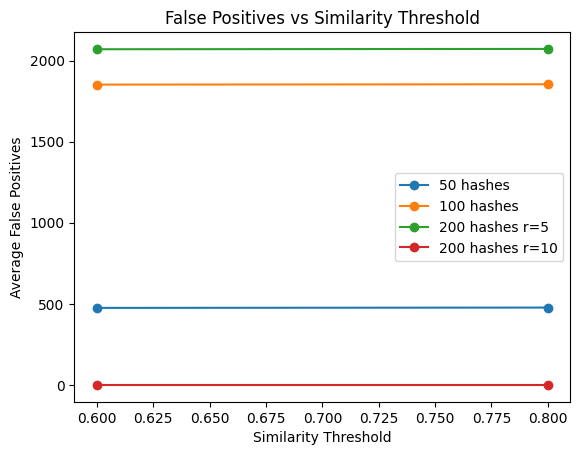

In [84]:
plt.figure()

for config in df["Configuration"].unique():
    subset = df[df["Configuration"] == config]
    plt.plot(subset["Threshold"], subset["False Positives"], marker='o')

plt.xlabel("Similarity Threshold")
plt.ylabel("Average False Positives")
plt.title("False Positives vs Similarity Threshold")
plt.legend(df["Configuration"].unique())
plt.show()

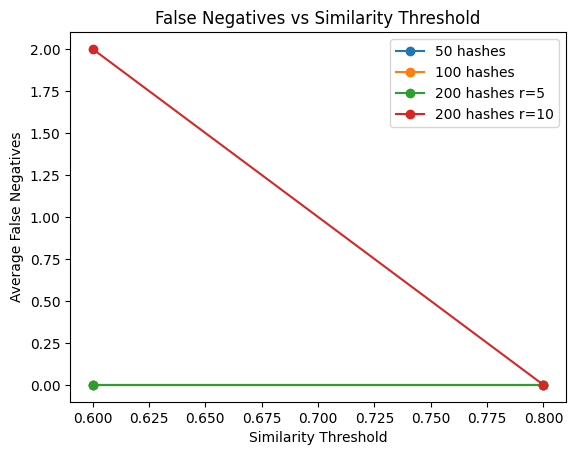

In [85]:
plt.figure()

for config in df["Configuration"].unique():
    subset = df[df["Configuration"] == config]
    plt.plot(subset["Threshold"], subset["False Negatives"], marker='o')

plt.xlabel("Similarity Threshold")
plt.ylabel("Average False Negatives")
plt.title("False Negatives vs Similarity Threshold")
plt.legend(df["Configuration"].unique())
plt.show()